In [2]:
import matplotlib.pyplot as plt
import numpy as np
import random
from scipy.stats import loguniform
from scipy.stats import gaussian_kde
import matplotlib.gridspec as gridspec

from src.formulas import raiteri_mass_from_lifetime
from src.load_data import load_hw2002, load_takahashi, load_ww95
from src.plot import plot_one_yield
from src.salvadori_funcs import salvadori_H_ratio, salvadori_combined_abundratio, salvadori_combined_abundratio_WrtH, salvadori_yields, salvadori_Y_X_II
from src.salvadori_funcs import salvadori_yields as salvadori_yields_convert
from src.utils import _combine_elements, _get_element

from params import ww95_001Z, filter_elements


hw_yields = load_hw2002()
takahashi_yields = load_takahashi()
takahashi_yields = takahashi_yields["NR"]
ww95_yields = load_ww95(ww95_001Z)

hw_yields = hw_yields[1:]

pisn_yields = hw_yields
sn_yields = ww95_yields

salvadori_pisn_yields = salvadori_yields_convert(pisn_yields)
salvadori_sn_yields = salvadori_yields_convert(sn_yields)

Processing element: C


/home/ardo/mlem/Vaults/Thesis/Repl/src/salvadori_funcs.py:406: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return quad(
/home/ardo/mlem/Vaults/Thesis/Repl/src/salvadori_funcs.py:347: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.

Processing element: N
Processing element: O


/home/ardo/mlem/Vaults/Thesis/Repl/src/salvadori_funcs.py:347: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(


Processing element: F
Processing element: Ne
Processing element: Na
Processing element: Mg
Processing element: Al
Processing element: Si
Processing element: S
Processing element: Cl
Processing element: Ar
Processing element: K
Processing element: Ca
Processing element: Sc
Processing element: Ti
Processing element: V
Processing element: Cr
Processing element: Mn
Processing element: Co
Processing element: Ni
Processing element: Cu
Processing element: Zn


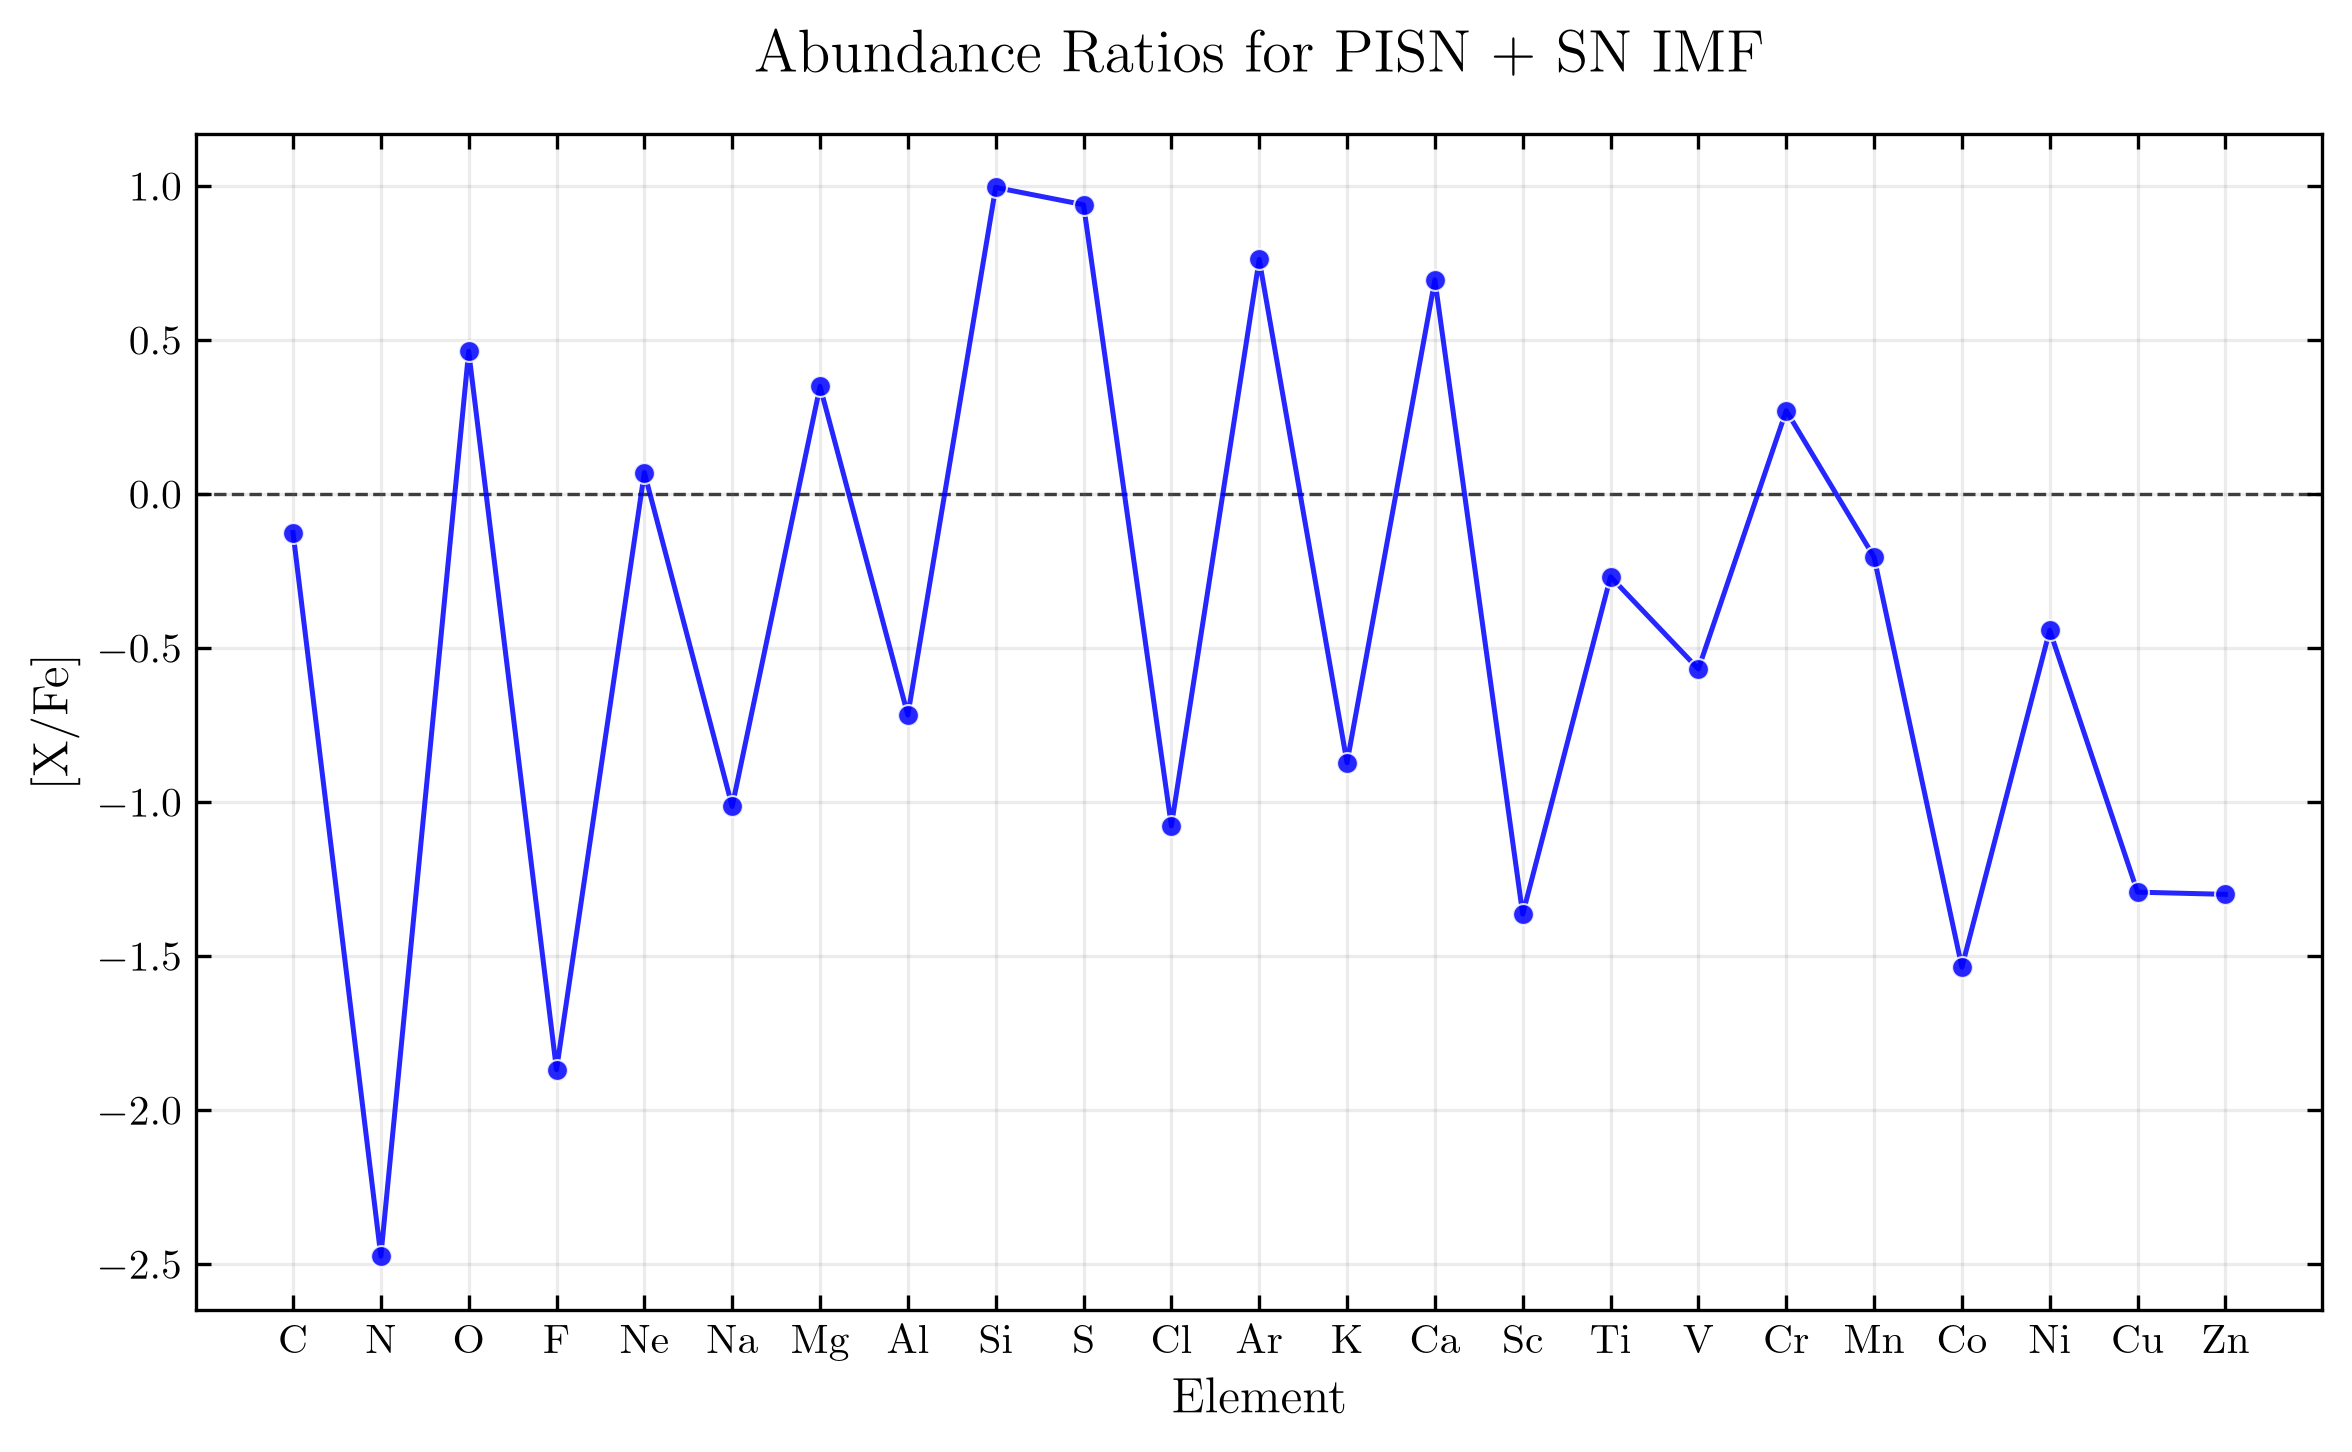

In [2]:
pisn_snIMF_ratios = {}
for elem in filter_elements:
    if elem in ["H", "He", "P", "Fe"]:
        continue

    print(f"Processing element: {elem}")

    current_ratios = []
    for i in range(500):
        
        pisn_entry = random.choice(salvadori_pisn_yields)

        f_pisn = 0.90
        f_ratio = loguniform.rvs(1e-4, 1e-1)
        tpop2_values = [3e6, 6e6, 10e6, 20e6, 30e6]
        tpop2 = random.choice(tpop2_values)

        combined_ratio = salvadori_combined_abundratio(elem,elem,"Fe","Fe", pisn_data=pisn_entry, sn_data=sn_yields, salv_sn_data=None, auto_sn=False, single_sn=False, f_pisn=f_pisn, f_ratio=f_ratio, tpop2=tpop2)
        current_ratios.append(combined_ratio)
    pisn_snIMF_ratios[elem] = sum(current_ratios) / len(current_ratios)

pisn_snIMF = plot_one_yield(pisn_snIMF_ratios, title="Abundance Ratios for PISN + SN IMF", filter_elements=filter_elements)

Processing element: C
Processing element: N
Processing element: O
Processing element: F
Processing element: Ne
Processing element: Na
Processing element: Mg
Processing element: Al
Processing element: Si
Processing element: S
Processing element: Cl
Processing element: Ar
Processing element: K
Processing element: Ca
Processing element: Sc
Processing element: Ti
Processing element: V
Processing element: Cr
Processing element: Mn
Processing element: Co
Processing element: Ni
Processing element: Cu
Processing element: Zn


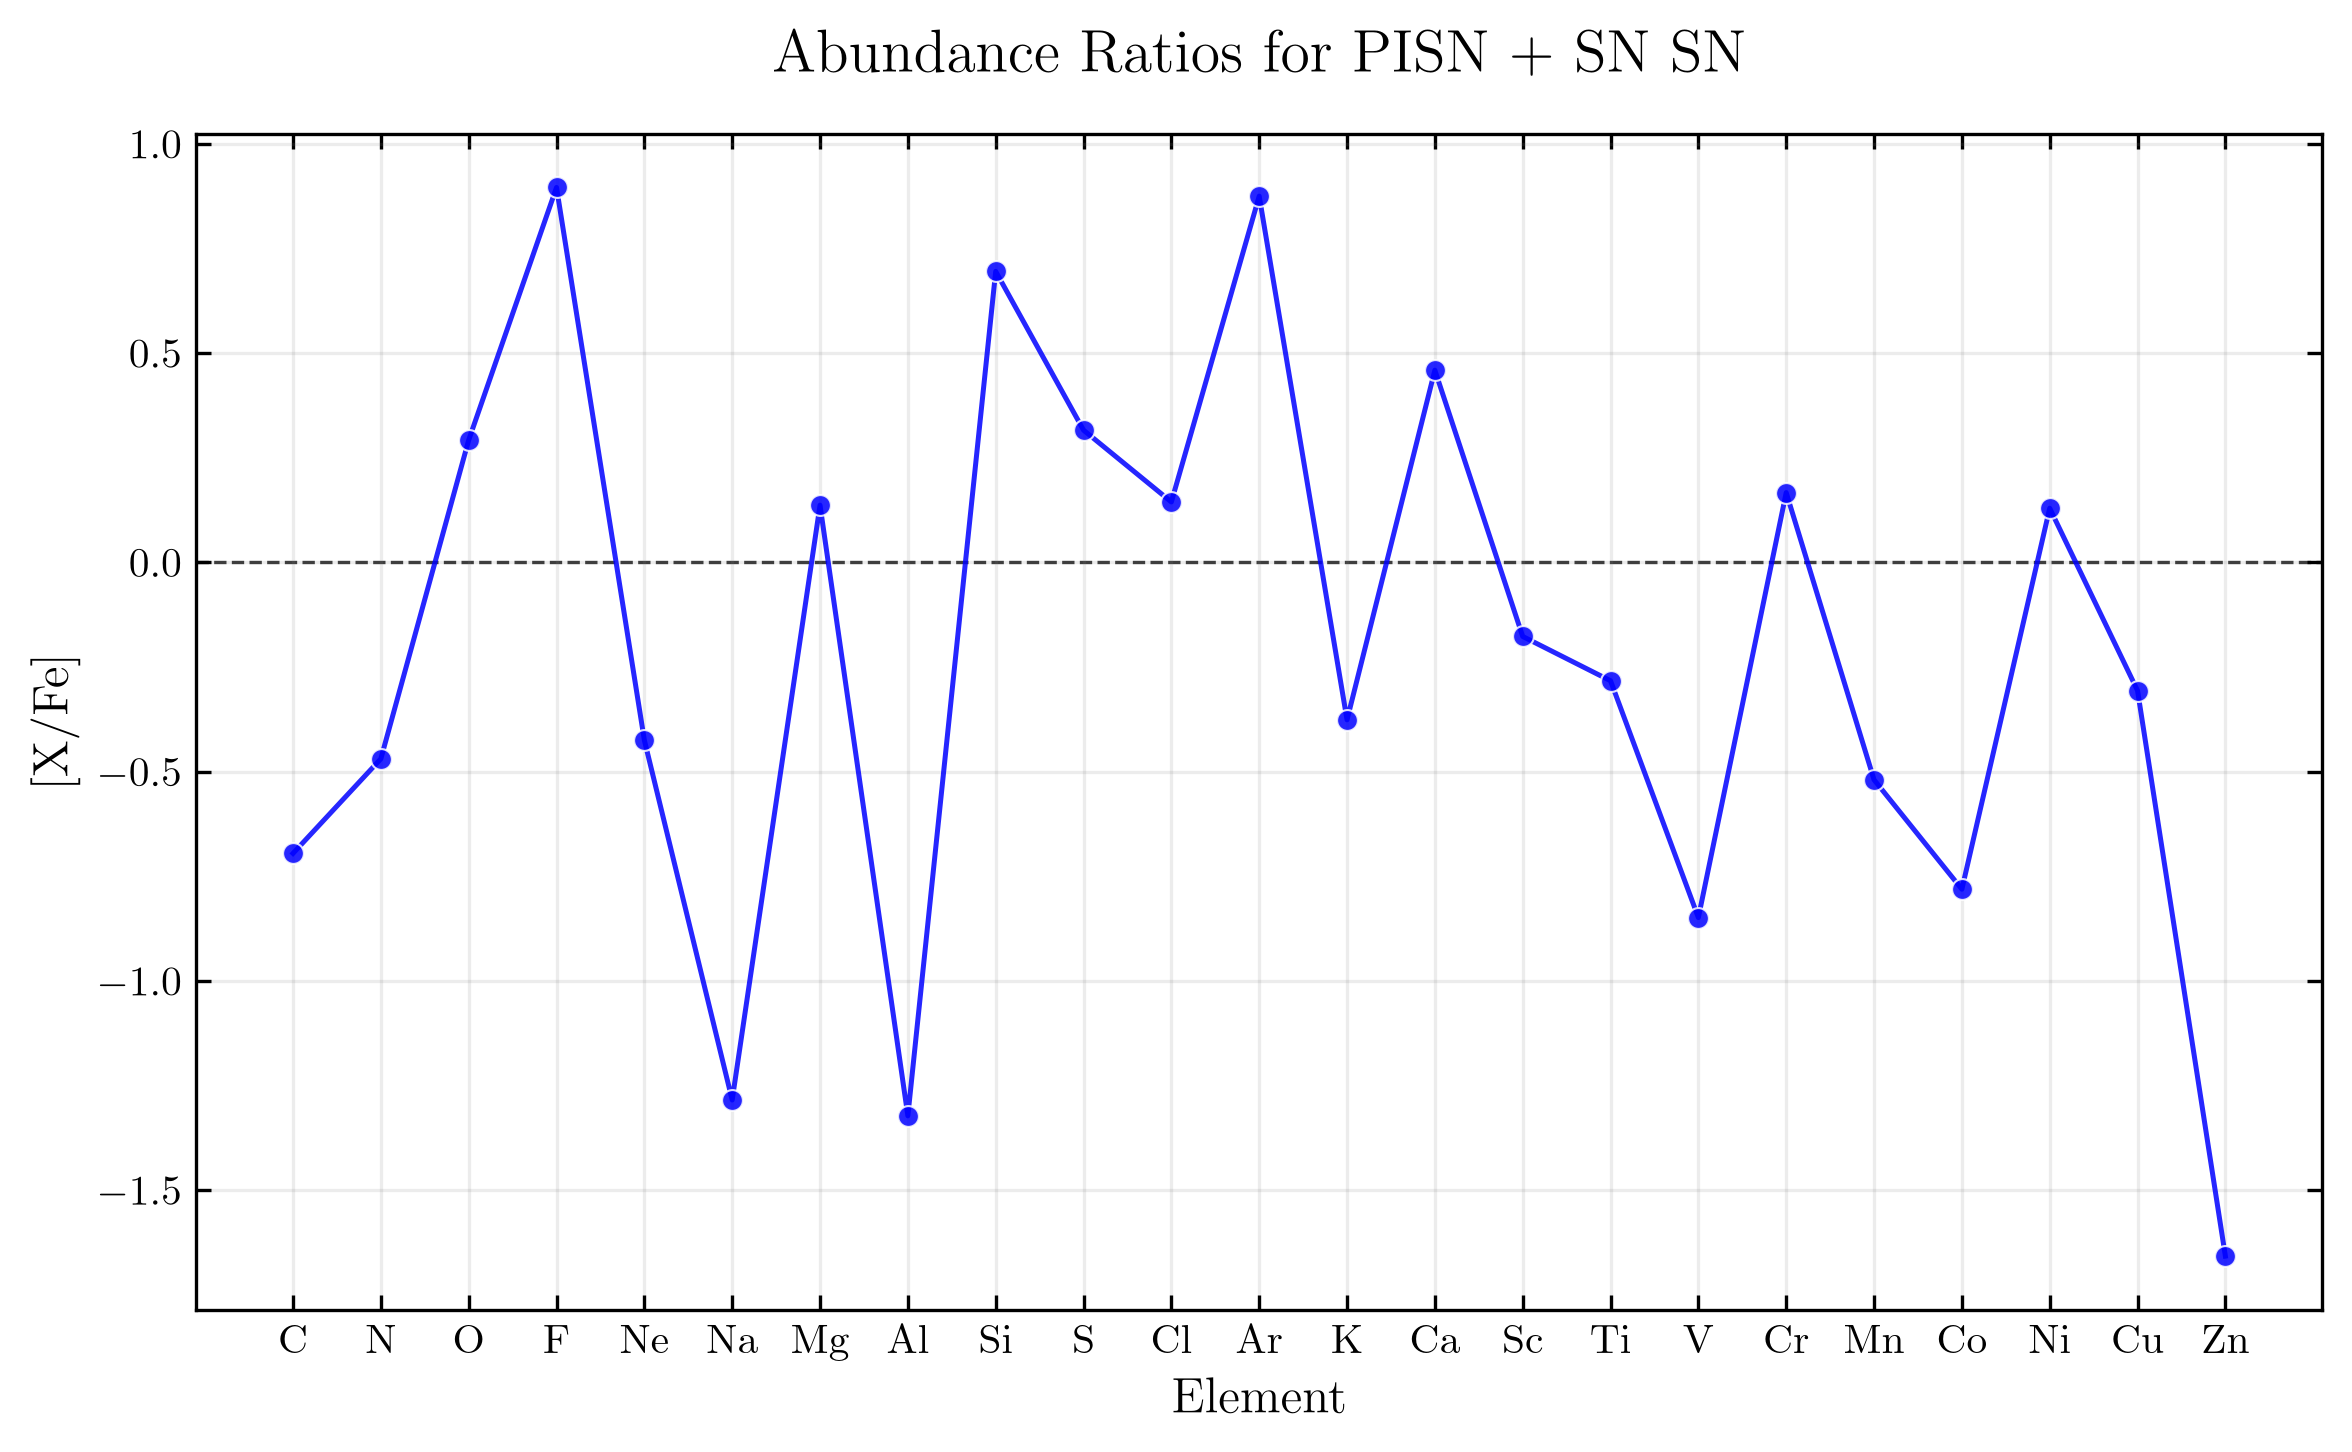

In [3]:
pisn_sn_ratios = {}
for elem in filter_elements:
    if elem in ["H", "He", "P", "Fe"]:
        continue

    print(f"Processing element: {elem}")

    pisn_entry = random.choice(salvadori_pisn_yields)
    sn_entry = random.choice(salvadori_sn_yields)

    f_pisn = 0.90
    f_ratio = loguniform.rvs(1e-4, 1e-1)
    tpop2_values = [3e6, 6e6, 10e6, 20e6, 30e6]
    tpop2 = random.choice(tpop2_values)

    combined_ratio = salvadori_combined_abundratio(elem,elem,"Fe","Fe", pisn_data=pisn_entry, sn_data=sn_yields, salv_sn_data=sn_entry, auto_sn=False, single_sn=True, f_pisn=f_pisn, f_ratio=f_ratio, tpop2=tpop2)
    pisn_sn_ratios[elem] = combined_ratio

pisn_snsn = plot_one_yield(pisn_sn_ratios, title="Abundance Ratios for PISN + SN SN", filter_elements=filter_elements)


Processing element: C
Processing element: N
Processing element: O
Processing element: F
Processing element: Ne
Processing element: Na
Processing element: Mg
Processing element: Al
Processing element: Si
Processing element: S
Processing element: Cl
Processing element: Ar
Processing element: K
Processing element: Ca
Processing element: Sc
Processing element: Ti
Processing element: V
Processing element: Cr
Processing element: Mn
Processing element: Co


/home/ardo/mlem/Vaults/Thesis/Repl/src/salvadori_funcs.py:347: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return quad(


Processing element: Ni
Processing element: Cu
Processing element: Zn


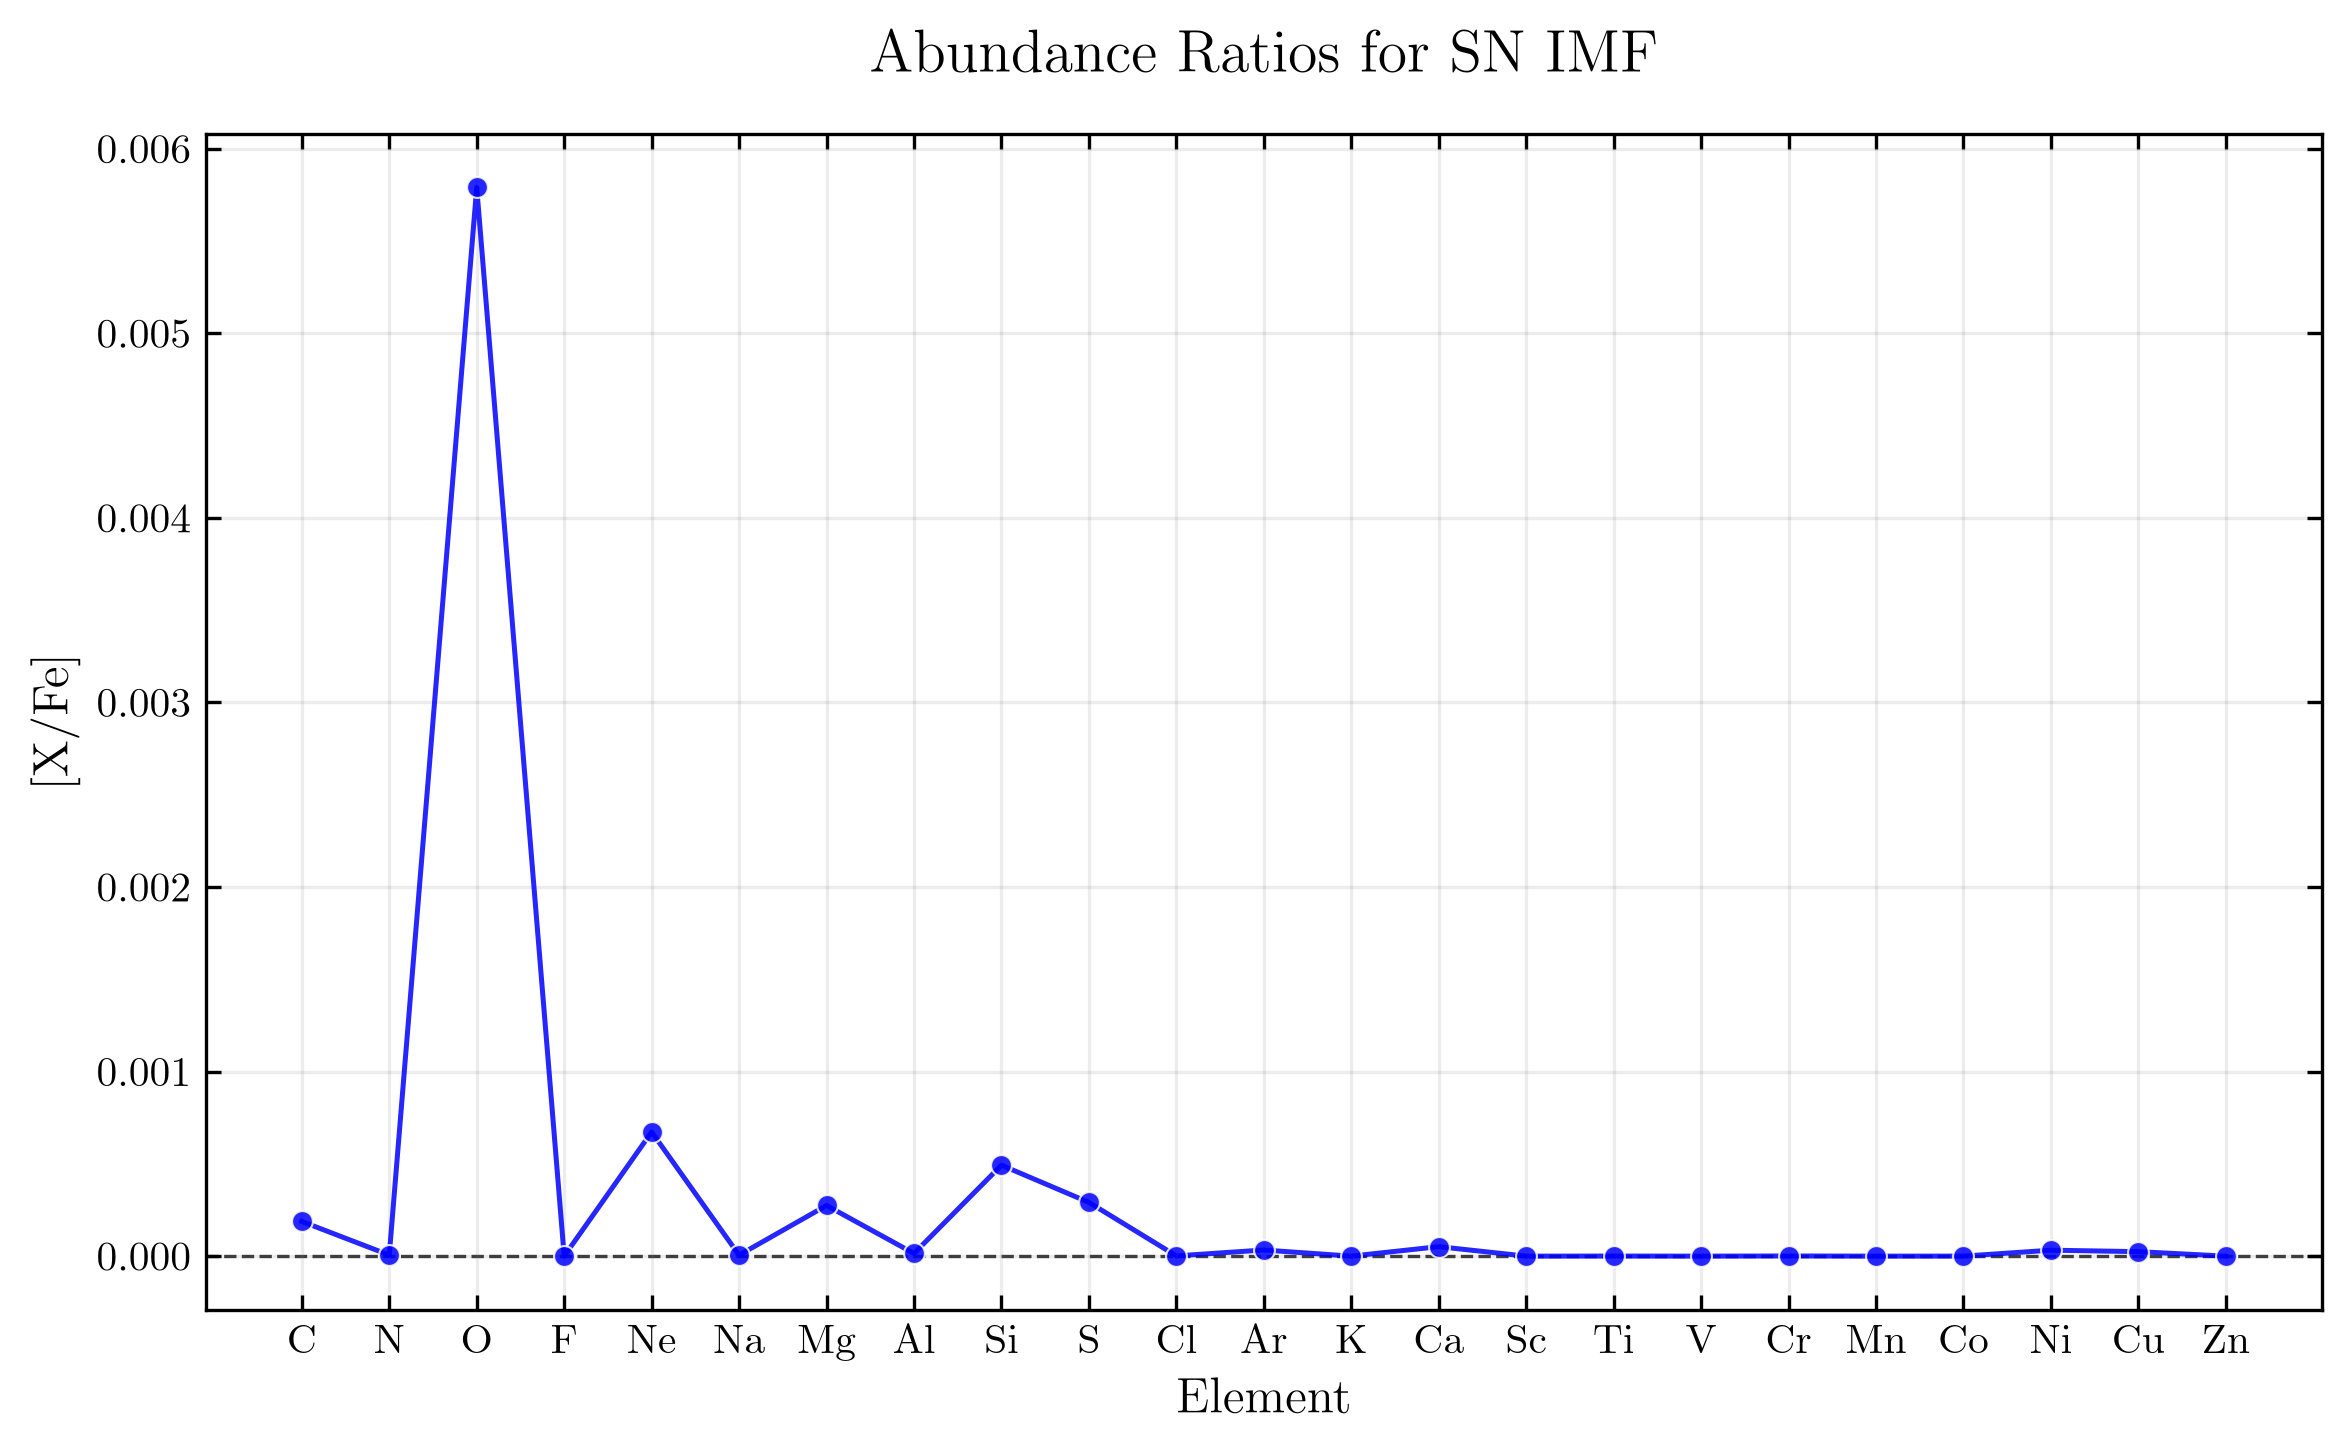

In [8]:
sn_IMF_ratios = {}
for elem in filter_elements:
    if elem in ["H", "He", "P", "Fe"]:
        continue

    print(f"Processing element: {elem}")

    sn_entry = random.choice(salvadori_sn_yields)

    f_ratio = loguniform.rvs(1e-4, 1e-1)
    tpop2_values = [3e6, 6e6, 10e6, 20e6, 30e6]
    tpop2 = random.choice(tpop2_values)

    pisn_data = random.choice(hw_yields)
    pisn_data["yields"] = _combine_elements(pisn_data["yields"])
    pisn_yields = pisn_data

    Yx1_pisn = _get_element(pisn_yields, elem)
    Yz_pisn = sum(
        e for element, e in pisn_yields["yields"].items()
        if element not in ("H", "He")
    )

    Z_star = f_ratio * Yz_pisn

    m_popII = raiteri_mass_from_lifetime(
        lifetime=tpop2,
        Z=Z_star,
    )

    combined_ratio = salvadori_Y_X_II(sn_yields, elem, m_popII=m_popII, model="A", m_max=100.0)
    sn_IMF_ratios[elem] = combined_ratio
sn_imf = plot_one_yield(sn_IMF_ratios, title="Abundance Ratios for SN IMF", filter_elements=filter_elements)


12 20.28697088043728
13 17.915876311588978
15 14.506482594477252
18 11.316996367316875
20 9.908333704821468
22 8.844411746867262
25 7.670377925320041
30 6.384852326489313
35 5.567201892426348
40 5.010628715793566


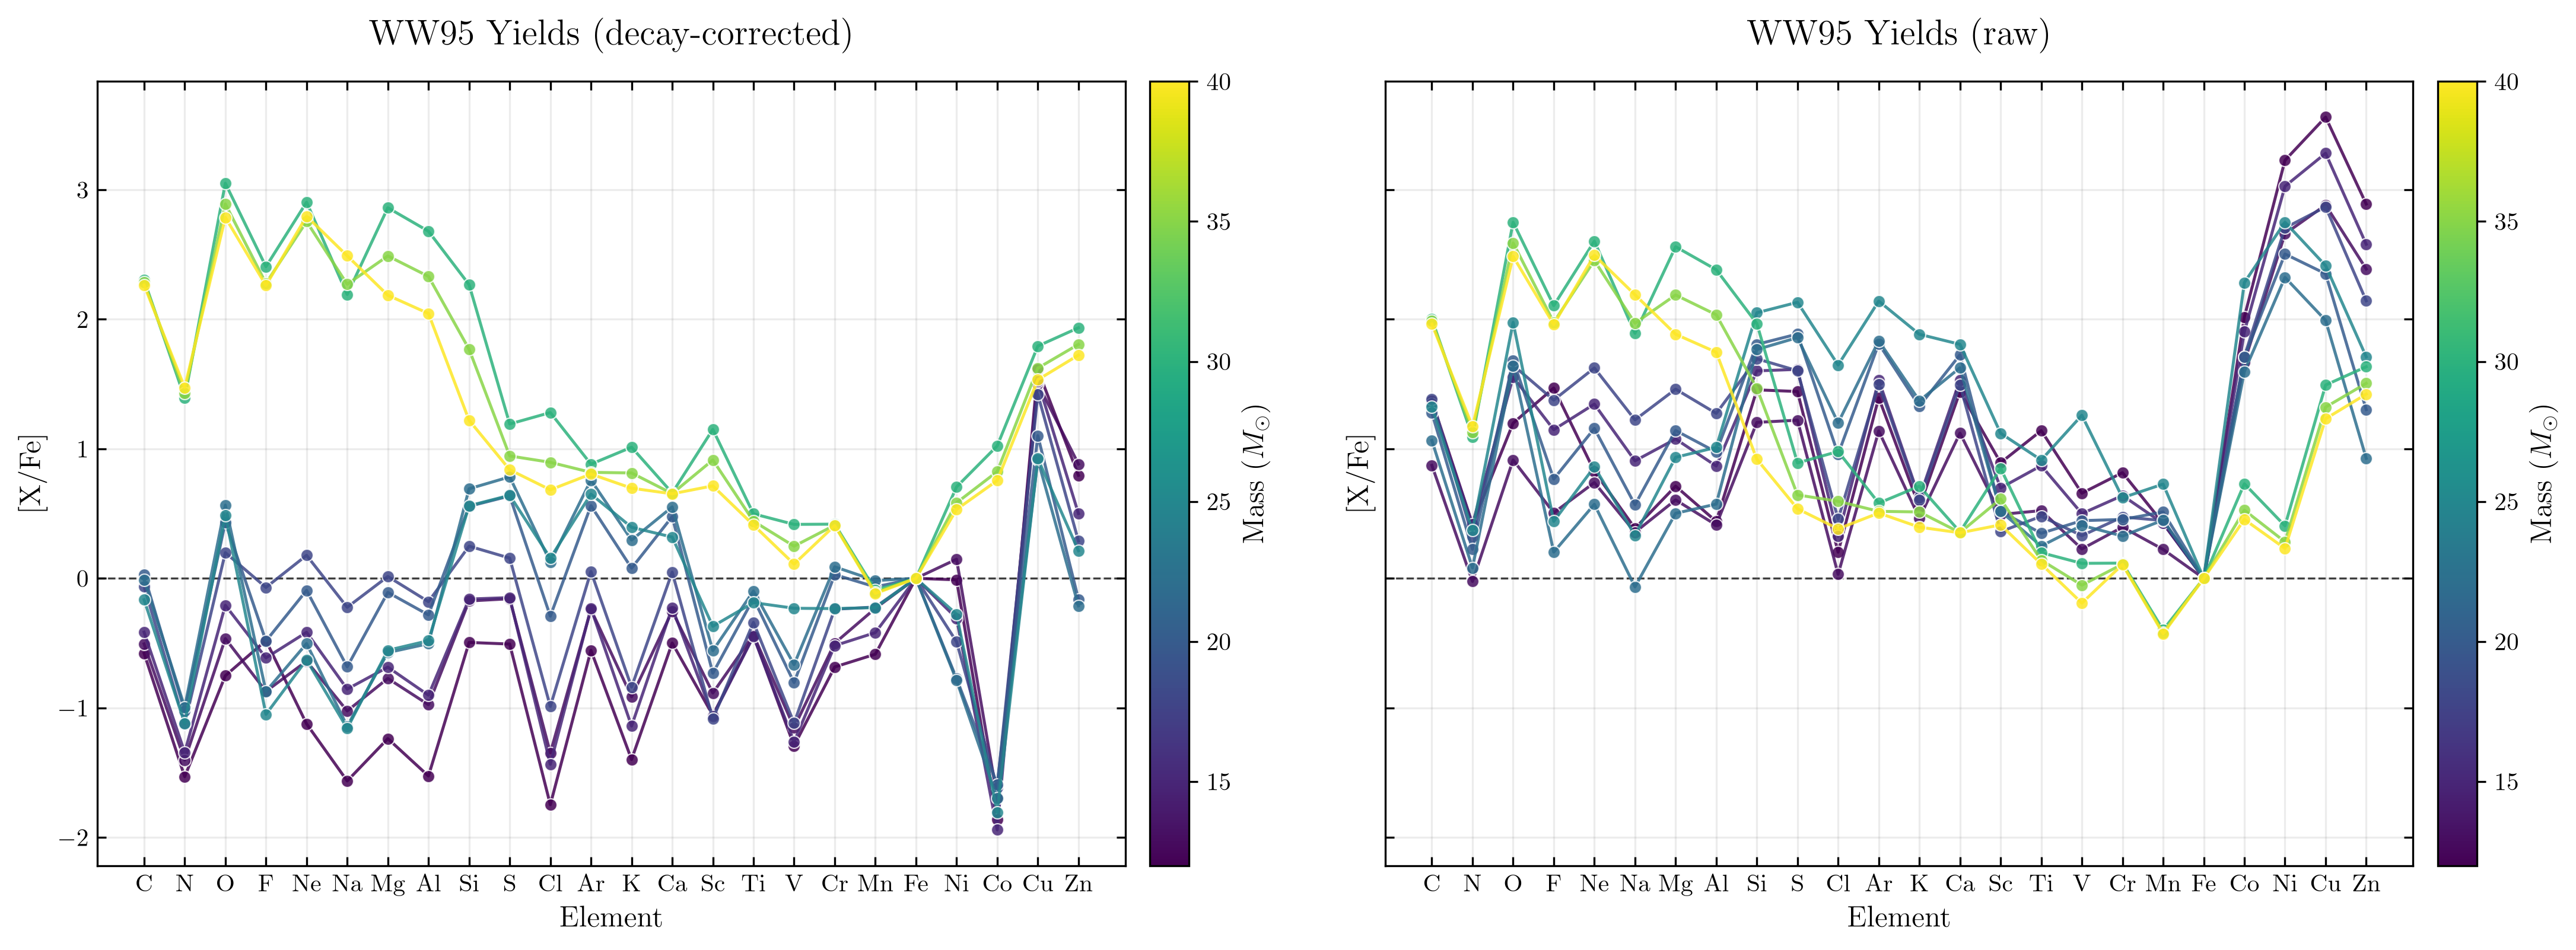

In [ ]:
from src.plot import plot_yields
from src.utils import _apply_radioactive_decay
from src.formulas import raiteri_lifetime

import copy

ww95_filtered = [entry for entry in ww95_yields if entry["params"]["model"] == "A"]

ww95_filt = copy.deepcopy(ww95_filtered)  # independent copy, not shared references

for i in ww95_filt:
    yields = i["yields"]
    timescale_yr = raiteri_lifetime(mass=i['params']['mass'], Z=0.01)
    print(i['params']['mass'],timescale_yr/1e6)
    combined_yields = _combine_elements(_apply_radioactive_decay(yields, timescale_yr))
    combined_yields['Fe'] = combined_yields.get('Fe', 0) * 0.5
    i["yields"] = combined_yields  # mutate the dict directly, no need for the .index() lookup

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)

plot_yields(ww95_filt, title="WW95 Yields (decay-corrected)", combine_elements=True,
            filter_elements=filter_elements, ax=axes[0])
plot_yields(ww95_filtered, title="WW95 Yields (raw)", combine_elements=True,
            filter_elements=filter_elements, ax=axes[1])

plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(15, 9),
    sharey=True
)

# Flatten axes for easy iteration
axes = axes.flatten()

elements = [
    elem for elem in filter_elements
    if elem not in ["H", "He", "P", "Fe"]
]

datasets = [
    (pisn_snIMF_ratios, "PISN + SN (IMF)"),
    (pisn_sn_ratios,    "PISN + SN (Single SN)"),
    (sn_IMF_ratios,     "SN (IMF)"),
    (sn_only_yield,     "SN (Single)")
]

for ax, (data, title) in zip(axes, datasets):

    ax.plot(
        elements,
        [data[elem] for elem in elements],
        marker="o",
        markersize=5,
        linewidth=1.2,
        alpha=0.85
    )

    ax.set_title(title, pad=12)

    ax.set_xticks(range(len(elements)))
    ax.set_xticklabels(
        [rf"$\mathrm{{{elem}}}$" for elem in elements]
    )

    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=True,
        right=True
    )

    ax.axhline(
        0,
        linestyle="--",
        color="black",
        linewidth=0.8,
        alpha=0.8,
        zorder=0
    )

    ax.grid(
        visible=True,
        which="major",
        color="gray",
        alpha=0.15,
        linestyle="-"
    )

    ax.set_xlabel("Element")

# Only left plots need the y-axis label
axes[0].set_ylabel("[X / Fe]")
axes[2].set_ylabel("[X / Fe]")

fig.suptitle(
    "Comparison of Enrichment Scenarios",
    fontsize=15,
    y=0.98
)

plt.tight_layout()
plt.show()